Официальная документация к соревнованию Higgs Boson Machine Learning Challenge. Цель - использовать методы машинного обучения для анализа столкновения частиц на БАК, и научиться эффективно отделять сигнал (рождение бозона Хиггса) от фона. Посмотрим, что находится внутри файла с данными

In [44]:
import pandas as pd

df = pd.read_csv("atlas-higgs-challenge-2014-v2.csv")

df.tail(5)


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label,KaggleSet,KaggleWeight
818233,918233,105.668,46.443,60.048,156.191,0.403,47.746,0.936,1.279,6.133,...,1.190,-0.766,41.791,0.787,-1.090,154.056,0.005721,s,u,0.259892
818234,918234,99.294,30.097,62.713,65.861,3.312,471.319,-2.611,2.294,2.889,...,1.293,-0.868,70.158,-2.018,2.893,178.856,0.000461,s,u,0.020956
818235,918235,108.497,9.837,65.149,18.006,-999.000,-999.000,-999.000,2.742,18.006,...,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000,1.189365,b,u,53.284258
818236,918236,96.711,20.006,66.942,29.761,-999.000,-999.000,-999.000,2.479,2.739,...,1.460,2.637,-999.000,-999.000,-999.000,30.863,0.512740,b,u,22.971060
818237,918237,92.373,80.109,77.619,3.984,-999.000,-999.000,-999.000,2.486,3.984,...,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000,1.531213,b,u,68.599269


Значения с PRI_ (primitive) - это сырые данные, непосредственно полученные с детектора. и DER_ (derivative?) - вычисленные по формулам. 

Разберем каждый столбец:

EventID - уникальный номер события (id)

Label - Целевой класс (метка) s - сигнал - рождение Хиггса  с распадом на два тау-лептона. b - фон - другие процессы.

Weight - Вес события. Нормализационный коэффициент, который отражает реальную математическую вероятность появления такого события. 

KaggleSet и KaggleWeight - технические колонки для соревнований.

DER_:

DER_mass_MMC - Missing mass calculator - расчетная масса системы двух тау-лептонов. Бозон Хиггса имеет массу около 125 ГэВ.

DER_mass_transverse_met_lep - поперечная масса, вычисленная на основе параметров лептона и недостающей энергии (MET). 

DER_mass_vis - "Видимая масса" системы лептона и тау-лептона

DER_pt_h - Восстановленный суммарный поперечный импульс кандидата на бозон Хиггса.

DER_deltaeta_jet_jet - Абсолютная разность псевдобыстрот($\Delta\eta$) между двумя ведущими струями (доступно только при PRI_jet_num $\ge 2$)  (Псевдобыстрота - Пространственный угол, характеризующий направление полета частицы относительно оси пучка. $\eta = 0$ означает, что частица летит строго перпендикулярно пучку (вглубь детектора). Чем больше $\eta$ по модулю, тем ближе траектория частицы к оси пучка.) 

DER_mass_jet_jet - инвариантная масса системы двух ведущих струй. (неопределена, если PRI_jet_num $\le 1$)

DER_prodeta_jet_jet - Произведение псевдобыстрот ($\eta_1 \times \eta_2$) двух ведущих струй. 

DER deltar tau lep - Расстояние $\Delta R = \sqrt{\Delta\eta^2 + \Delta\phi^2}$ между тау-лептоном и обычным лептоном в пространстве детектора. Показывает, насколько близко друг к другу они полетели.

DER_pt_tot - Полный векторный остаточный поперечный импульс всей системы (в идеальном случае должен быть равен нулю, отклонения говорят о качестве реконструкции или неучтенных деталях).

DER_sum_pt - Простая скалярная сумма поперечных импульсов лептона, тау-лептона и всех джетов

DER_pt_ratio_lep_tau - Отношение поперечного импульса лептона к поперечному импульсу тау-лептона.

DER_met_phi_centrality - Показывает, насколько угловое направление недостающей энергии (MET) находится "между" лептоном и тау.

DER_lep_eta_centrality - Измеряет "центральность" лептона относительно двух ведущих струй частиц (доступно только при PRI_jet_num $\ge$ 2).

PRI_tau_pt, PRI_tau_eta, PRI_tau_phi: Поперечный импульс, псевдобыстрота и азимутальный угол тау-лептона, который распался с образованием адронов.

RI_lep_pt, PRI_lep_eta, PRI_lep_phi: Импульс и углы "легкого" лептона (электрона или мюона), получившегося в результате распада второго тау-лептона.

PRI_met, PRI_met_phi: Missing Transverse Energy (MET) — недостающая поперечная энергия и её угол. Детекторы улавливают не все частицы. Нейтрино улетают незамеченными, унося энергию. MET показывает, сколько энергии «пропало» и в какую сторону она была направлена.

PRI_met_sumet: Скалярная сумма всей поперечной энергии, зарегистрированной в калориметрах детектора.

PRI_jet_num: Количество адронных струй (джетов) в событии. Может принимать значения 0, 1, 2 или 3 (3 означает "3 или более"). Внимание: если джетов мало (например, 0 или 1), то характеристики для недостающих джетов физически невозможно измерить. В этом случае в таблице стоит заглушка -999.0.

PRI_jet_leading_pt, _eta, _phi: Параметры самой высокоэнергетической (ведущей) струи частиц. Если PRI_jet_num = 0, здесь будет стоять -999.0.

PRI_jet_subleading_pt, _eta, _phi: Параметры второй по энергии струи частиц. Доступны, только если PRI_jet_num $\ge$ 2, иначе равен -999.0.

PRI_jet_all_pt: Скалярная сумма поперечных импульсов всех обнаруженных джетов в событии.

In [2]:
df.shape #количество строк в датафрейме

(818238, 35)

In [3]:
df.dtypes #типы данных в столбцах

EventId                          int64
DER_mass_MMC                   float64
DER_mass_transverse_met_lep    float64
DER_mass_vis                   float64
DER_pt_h                       float64
DER_deltaeta_jet_jet           float64
DER_mass_jet_jet               float64
DER_prodeta_jet_jet            float64
DER_deltar_tau_lep             float64
DER_pt_tot                     float64
DER_sum_pt                     float64
DER_pt_ratio_lep_tau           float64
DER_met_phi_centrality         float64
DER_lep_eta_centrality         float64
PRI_tau_pt                     float64
PRI_tau_eta                    float64
PRI_tau_phi                    float64
PRI_lep_pt                     float64
PRI_lep_eta                    float64
PRI_lep_phi                    float64
PRI_met                        float64
PRI_met_phi                    float64
PRI_met_sumet                  float64
PRI_jet_num                      int64
PRI_jet_leading_pt             float64
PRI_jet_leading_eta      

In [4]:
df.describe()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,KaggleWeight
count,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,...,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000,818238.000000
mean,509118.500000,-48.819019,49.252714,81.140561,57.849524,-707.740880,-600.191191,-708.681306,2.373871,18.969617,...,0.979923,-348.757840,-399.693294,-399.703858,-691.626111,-708.442206,-708.443312,73.205594,0.503144,2.012577
std,236205.109118,406.118397,35.378609,40.582708,63.411938,454.793899,658.724040,453.328599,0.780875,21.918491,...,0.978793,533.097006,489.428560,489.420013,480.274744,453.699150,453.697158,98.331754,0.572200,5.439641
min,100000.000000,-999.000000,0.000000,6.329000,0.000000,-999.000000,-999.000000,-999.000000,0.208000,0.000000,...,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-0.000000,0.000461,0.000839
25%,304559.250000,78.166000,19.304000,59.414000,14.164250,-999.000000,-999.000000,-999.000000,1.814000,2.839000,...,0.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,0.000000,0.005721,0.010415
50%,509118.500000,105.061000,46.484000,73.744000,38.470000,-999.000000,-999.000000,-999.000000,2.492000,12.383000,...,1.000000,38.965000,-1.865000,-2.105000,-999.000000,-999.000000,-999.000000,40.506000,0.357223,0.806562
75%,713677.750000,130.730000,73.620000,92.188000,79.226750,0.499000,84.031750,-4.548000,2.962000,27.634000,...,2.000000,75.470750,0.432000,0.489000,33.800000,-2.436000,-2.265000,110.387000,0.733462,2.360271
max,918237.000000,1949.261000,968.669000,1349.351000,2834.999000,8.724000,4974.979000,17.650000,5.751000,2834.999000,...,3.000000,1163.439000,4.500000,3.142000,817.801000,4.500000,3.142000,1860.175000,2.386316,106.908407


In [5]:
df.isnull().sum() #проверяем пропуски

EventId                        0
DER_mass_MMC                   0
DER_mass_transverse_met_lep    0
DER_mass_vis                   0
DER_pt_h                       0
DER_deltaeta_jet_jet           0
DER_mass_jet_jet               0
DER_prodeta_jet_jet            0
DER_deltar_tau_lep             0
DER_pt_tot                     0
DER_sum_pt                     0
DER_pt_ratio_lep_tau           0
DER_met_phi_centrality         0
DER_lep_eta_centrality         0
PRI_tau_pt                     0
PRI_tau_eta                    0
PRI_tau_phi                    0
PRI_lep_pt                     0
PRI_lep_eta                    0
PRI_lep_phi                    0
PRI_met                        0
PRI_met_phi                    0
PRI_met_sumet                  0
PRI_jet_num                    0
PRI_jet_leading_pt             0
PRI_jet_leading_eta            0
PRI_jet_leading_phi            0
PRI_jet_subleading_pt          0
PRI_jet_subleading_eta         0
PRI_jet_subleading_phi         0
PRI_jet_al

In [6]:
df.nunique() #количество уникальных значений в каждом столбце

EventId                        818238
DER_mass_MMC                   177622
DER_mass_transverse_met_lep    131888
DER_mass_vis                   154516
DER_pt_h                       190925
DER_deltaeta_jet_jet             7665
DER_mass_jet_jet               197975
DER_prodeta_jet_jet             21893
DER_deltar_tau_lep               5018
DER_pt_tot                      84683
DER_sum_pt                     285774
DER_pt_ratio_lep_tau             7464
DER_met_phi_centrality           2829
DER_lep_eta_centrality           1002
PRI_tau_pt                      86459
PRI_tau_eta                      4979
PRI_tau_phi                      6285
PRI_lep_pt                      88725
PRI_lep_eta                      5002
PRI_lep_phi                      6285
PRI_met                        126055
PRI_met_phi                      6285
PRI_met_sumet                  348080
PRI_jet_num                         4
PRI_jet_leading_pt             152062
PRI_jet_leading_eta              8902
PRI_jet_lead

In [7]:
df.duplicated().sum() #проверяем дубликаты

np.int64(0)

Для обучения модели понадобятся веса, поэтому перед удалением запишем их в переменную.

In [45]:
weights = df['Weight'].values

Раз дубликатов нет, удалим столбцы, которые не должны быть использованы при обучении модели

In [46]:
columns_to_drop = ['EventId', 'KaggleSet', 'Weight', 'KaggleWeight']
df = df.drop(columns=columns_to_drop)

In [47]:
df.head(5)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,s
1,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,b
2,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,b
3,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,b
4,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,b


Перекодируем признак Label в 0 для b и 1 для s

In [48]:
df['Label'] = df['Label'].map({'s': 1, 'b': 0}) #преобразуем метки классов в числовые значения
df.head(5)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,1
1,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,0
2,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,0
3,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,0
4,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,0


In [12]:
(df==-999.0).sum() #проверяем количество -999.0 в каждом столбце

DER_mass_MMC                   124602
DER_mass_transverse_met_lep         0
DER_mass_vis                        0
DER_pt_h                            0
DER_deltaeta_jet_jet           580253
DER_mass_jet_jet               580253
DER_prodeta_jet_jet            580253
DER_deltar_tau_lep                  0
DER_pt_tot                          0
DER_sum_pt                          0
DER_pt_ratio_lep_tau                0
DER_met_phi_centrality              0
DER_lep_eta_centrality         580253
PRI_tau_pt                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_lep_pt                          0
PRI_lep_eta                         0
PRI_lep_phi                         0
PRI_met                             0
PRI_met_phi                         0
PRI_met_sumet                       0
PRI_jet_num                         0
PRI_jet_leading_pt             327371
PRI_jet_leading_eta            327371
PRI_jet_leading_phi            327371
PRI_jet_subl

Для таких данных хорошо подойдет XGBoost, так как он быстрый, способен работать с неуказанными значениями и значениями -999. В данном датасете нельзя заменить значения -999 на какие-то другие, потому что это буквально показывает, что их невозможно вычислить. Поэтому будем реализовывать модель XGBoost.

In [49]:
df.where(df != -999.0, inplace=True)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Label
0,138.470,51.655,97.827,27.980,0.910,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.240,-2.475,113.497,1
1,160.937,68.768,103.235,48.146,NaN,NaN,NaN,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,NaN,NaN,NaN,46.226,0
2,NaN,162.172,125.953,35.635,NaN,NaN,NaN,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,NaN,NaN,NaN,44.251,0
3,143.905,81.417,80.943,0.414,NaN,NaN,NaN,3.310,0.414,75.968,...,86.062,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,0
4,175.864,16.915,134.805,16.405,NaN,NaN,NaN,3.891,16.405,57.983,...,53.131,0,NaN,NaN,NaN,NaN,NaN,NaN,0.000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818233,105.668,46.443,60.048,156.191,0.403,47.746,0.936,1.279,6.133,256.853,...,303.668,2,112.264,1.190,-0.766,41.791,0.787,-1.090,154.056,1
818234,99.294,30.097,62.713,65.861,3.312,471.319,-2.611,2.294,2.889,248.582,...,266.919,2,108.698,1.293,-0.868,70.158,-2.018,2.893,178.856,1
818235,108.497,9.837,65.149,18.006,NaN,NaN,NaN,2.742,18.006,68.097,...,188.648,0,NaN,NaN,NaN,NaN,NaN,NaN,-0.000,0
818236,96.711,20.006,66.942,29.761,NaN,NaN,NaN,2.479,2.739,101.676,...,212.565,1,30.863,1.460,2.637,NaN,NaN,NaN,30.863,0


In [50]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label'].values  
X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(X, y, weights, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(X_temp, y_temp, w_temp, test_size=0.2, stratify=y_temp)

X_train_rf = X_train.copy()
X_val_rf =  X_val.copy() # сохраняем структуру данных для других моделей
X_test_rf = X_test.copy()

In [51]:
import xgboost as xgb
from xgboost import XGBClassifier

dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)
dtest = xgb.DMatrix(X_test)

params = {
    'objective': 'binary:logistic',  # классификация 0/1 с вероятностями
    'eval_metric': 'auc',            # метрика качества (площадь под ROC-кривой)
    'max_depth': 6,                  # глубина дерева (не слишком глубокое, чтобы не переобучить)
    'eta': 0.05,                     # шаг обучения (чем меньше, тем точнее, но дольше)
    'subsample': 0.8,                # доля данных для каждого дерева (защита от переобучения)
    'colsample_bytree': 0.8,         # доля признаков для каждого дерева
    'device': 'cuda'
}

sum_wpos = sum(w_train[y_train == 1])
sum_wneg = sum(w_train[y_train == 0])

params['scale_pos_weight'] = sum_wneg / sum_wpos # балансировка классов по весам (важно при дисбалансе классов). То есть это множитель для сигнала, чтобы компенсировать огромное количество фона.
#Так бы модель могла бы просто предсказывать "фон" и получать высокую точность, но с балансировкой классов она будет вынуждена обращать внимание на сигнальные события.


model = xgb.train(
    params, 
    dtrain, 
    num_boost_round=1000, 
    evals=[(dtrain, 'train'), (dval, 'eval')], # evals показывает, как модель ведет себя на обучающей и валидационной выборках
    early_stopping_rounds=50, # остановиться, если на валидации нет прогресса 50 раундов
    verbose_eval=50          # выводить результат каждые 50 итераций
)


[0]	train-auc:0.90909	eval-auc:0.90790
[50]	train-auc:0.92924	eval-auc:0.92731
[100]	train-auc:0.93473	eval-auc:0.93219
[150]	train-auc:0.93739	eval-auc:0.93406
[200]	train-auc:0.93927	eval-auc:0.93509
[250]	train-auc:0.94074	eval-auc:0.93569
[300]	train-auc:0.94212	eval-auc:0.93615
[350]	train-auc:0.94334	eval-auc:0.93646
[400]	train-auc:0.94441	eval-auc:0.93665
[450]	train-auc:0.94539	eval-auc:0.93677
[500]	train-auc:0.94635	eval-auc:0.93681
[550]	train-auc:0.94725	eval-auc:0.93690
[600]	train-auc:0.94809	eval-auc:0.93694
[650]	train-auc:0.94891	eval-auc:0.93697
[689]	train-auc:0.94958	eval-auc:0.93697


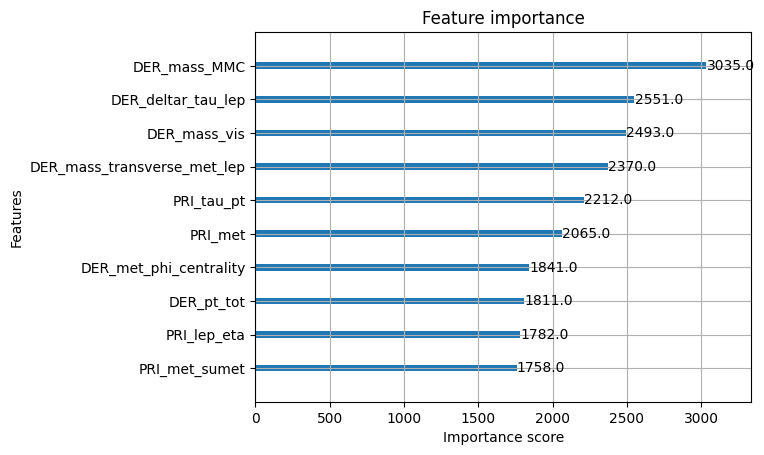

In [52]:

import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10)
plt.show()

In [53]:
y_pred = model.predict(dval) #возвращает вероятности
#нужно преобразовать вероятности в классы, используя порог 0.8
y_pred_class = (y_pred >= 0.8).astype(int)


In [54]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score


conf_matrix = confusion_matrix(y_true=y_val, y_pred=y_pred_class, sample_weight=w_val)
conf_matrix

array([[6.24501840e+04, 3.28382192e+03],
       [3.81503146e+01, 7.19059859e+01]])

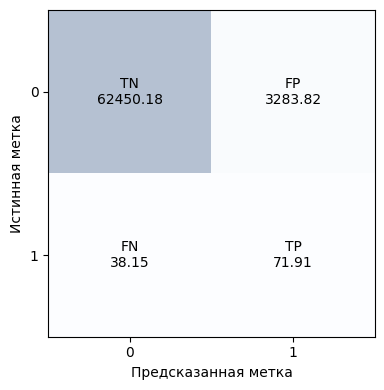

In [55]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
ax: plt.Axes = ax
ax.matshow(conf_matrix, cmap=plt.cm.Blues, alpha=0.3)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(x=j, y=i, s=f'{"T" if i == j else "F"}{"P" if j == 1 else "N"}\n{conf_matrix[i, j]:.2f}',
                va='center', ha='center')
ax.xaxis.set_ticks_position('bottom')
ax.set_xlabel('Предсказанная метка')
ax.set_ylabel('Истинная метка')
plt.tight_layout()
plt.show()

In [56]:
precision = precision_score(y_val, y_pred_class, sample_weight=w_val)
precision

0.021427835604197778

In [57]:
recall = recall_score(y_val, y_pred_class, sample_weight=w_val)
recall

0.6533563782726068

In [58]:
f1 = f1_score(y_val, y_pred_class, sample_weight=w_val)
f1

0.04149478537485603

Очень много фона, поэтому эти метрики не помогают оценить качество модели, используем ROC-кривую

In [59]:
auc = roc_auc_score(y_val, y_pred, sample_weight=w_val)
print(f"ROC AUC: {auc:.4f}")

ROC AUC: 0.9370


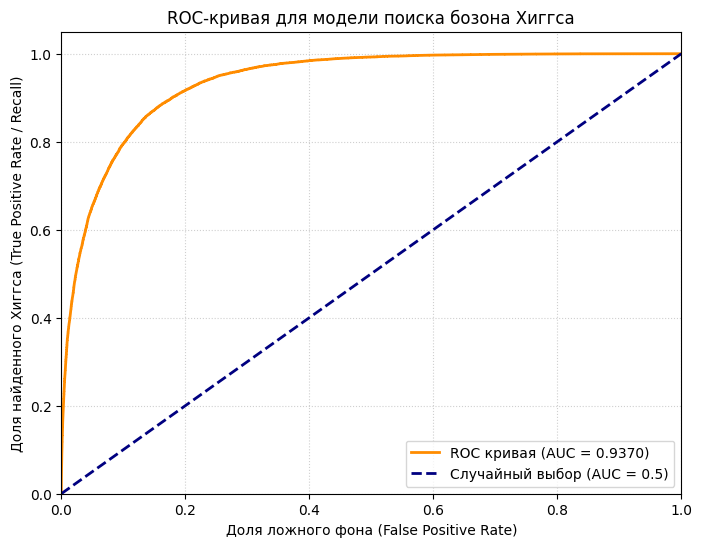

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


#Получаем координаты точек ROC-кривой
# fpr - доля ложноположительных ответов (False Positive Rate)
# tpr - доля истинно положительных ответов (True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)


plt.figure(figsize=(8, 6))


plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный выбор (AUC = 0.5)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Доля ложного фона (False Positive Rate)')
plt.ylabel('Доля найденного Хиггса (True Positive Rate / Recall)')
plt.title('ROC-кривая для модели поиска бозона Хиггса')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()

In [61]:
auc = roc_auc_score(y_val, y_pred, sample_weight=w_val)
f'AUC = {auc:.4f}'

'AUC = 0.9370'

Считаем метрику AMS, потому что по ней лучше всего видно, насколько хорошо обучена модель$$AMS = \sqrt{2 \left( (s + b + b_{\text{reg}}) \ln \left(1 + \frac{s}{b + b_{\text{reg}}} \right) - s \right)}$$
s - сумма физических весов истинных бозонов Хиггса, которые модель верно объявила сигналом (True Positives).

b (background) — сумма физических весов фона, который модель ошибочно объявила сигналом (False Positives).

$b_{\text{reg}} = 10$ — константа регуляризации. Она нужна для того, чтобы защитить метрику от случайных флуктуаций. Если бы её не было, модель могла бы случайно отобрать всего 1 идеальный Хиггс при $b=0$ и получить огромный, но нечестный AMS.

In [62]:
import numpy as np

def AMS_formula(s, b, b_reg=10):
    if b + b_reg <= 0:
        return 0
    val = (s + b + b_reg) * np.log(1 + s / (b + b_reg)) - s
    return np.sqrt(2 * val) if val > 0 else 0.0

In [63]:
top_fraction = 0.15
threshold = np.percentile(y_pred, 100 * (1 - top_fraction))
y_pred_binary = (y_pred >= threshold).astype(int)

s = np.sum(w_val[(y_val == 1) & (y_pred_binary == 1)]) #взвешенное количество правильно предсказанных сигналов TP
b = np.sum(w_val[(y_val == 0) & (y_pred_binary == 1)]) #взвешенное количество неправильно предсказанных сигналов (ложные срабатывания) FP
ams_score = AMS_formula(s, b)
f'AMS = {ams_score:.4f}'

'AMS = 1.4817'

Не прям вау AMS, но для одного XGBoost очень даже неплохо, очень хорошо даже. Меняя порог, можно повысить метрику AMS

Интересно будет обучить ансамбль RandomForest и Нейросеть, чтобы потом собрать ансамль ансамблей (Блендинг), что по идее должно сильно повысить качество обучения. Там где неуверена одна модель, ее "подстрахует" другая

К сожалению, нужно как-то обработать данные в таблице, заменить NaN на какие-то значения, потому что и RandomForest и Нейросеть плохо справляются с такими значениями. Мы попробуем заменить значения в всех столбцах на медиану, при этом эти значения будут фальшивы, но модели должны с этим справиться. Для всех столбцов добавим столбец-индикатор, что здесь присутствует пропущенное значение.

In [64]:
missing_cols = X_train_rf.columns[X_train_rf.isnull().any()].tolist()

median_dict = {col: X_train_rf[col].median() for col in missing_cols}
for col in missing_cols:
    X_train_rf[f'{col}_was_missing'] = X_train_rf[col].isnull().astype(float)
    X_val_rf[f'{col}_was_missing'] = X_val_rf[col].isnull().astype(float)
    X_test_rf[f'{col}_was_missing'] = X_test_rf[col].isnull().astype(float)

   
X_train_rf.fillna(median_dict, inplace=True)
X_val_rf.fillna(median_dict, inplace=True)
X_test_rf.fillna(median_dict, inplace=True)

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,DER_deltaeta_jet_jet_was_missing,DER_mass_jet_jet_was_missing,DER_prodeta_jet_jet_was_missing,DER_lep_eta_centrality_was_missing,PRI_jet_leading_pt_was_missing,PRI_jet_leading_eta_was_missing,PRI_jet_leading_phi_was_missing,PRI_jet_subleading_pt_was_missing,PRI_jet_subleading_eta_was_missing,PRI_jet_subleading_phi_was_missing
548910,159.700,0.856,107.834,117.599,3.370,454.408,-0.726,2.287,0.556,258.147,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
647672,111.940,37.256,45.664,320.582,5.088,2118.390,-6.230,0.738,1.812,590.567,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
568669,149.118,80.951,72.373,81.028,2.101,225.673,-0.242,2.746,12.686,147.678,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
126540,155.694,26.703,97.463,59.001,2.101,225.673,-0.242,2.933,20.071,148.658,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
71492,204.997,75.248,140.136,77.806,0.763,223.294,2.221,3.264,46.738,315.186,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350827,169.534,47.727,126.881,6.253,2.101,225.673,-0.242,3.792,6.253,68.463,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
612077,90.908,7.971,63.510,44.484,2.101,225.673,-0.242,2.664,20.203,91.655,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
74155,222.123,83.345,130.075,37.194,2.101,225.673,-0.242,3.634,0.839,106.937,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
580762,97.466,55.187,68.946,31.901,2.101,225.673,-0.242,2.622,1.693,102.769,...,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0


In [65]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=300,       
    max_depth=15,           
    min_samples_leaf=10,    
    n_jobs=-1,              
    random_state=42
)

rf_model.fit(X_train_rf, y_train, sample_weight=w_train)

pred_rf = rf_model.predict_proba(X_val_rf)[:, 1]


In [66]:
pred_rf

array([2.66109676e-01, 7.41650588e-04, 2.68261900e-02, ...,
       1.80336914e-02, 8.38149235e-01, 1.16550087e-01], shape=(130918,))

In [67]:
y_pred_rf_xgb = y_pred * 0.8 + pred_rf * 0.2

In [68]:
top_fraction = 0.15
threshold = np.percentile(y_pred_rf_xgb, 100 * (1 - top_fraction)) #сортирует вероятности и выбирает порог, который отделяет топ 15% предсказаний от остальных
y_pred_rf_xgb_binary = (y_pred_rf_xgb >= threshold).astype(int)

s = np.sum(w_val[(y_val == 1) & (y_pred_rf_xgb_binary == 1)]) #взвешенное количество правильно предсказанных сигналов TP
b = np.sum(w_val[(y_val == 0) & (y_pred_rf_xgb_binary == 1)]) #взвешенное количество неправильно предсказанных сигналов (ложные срабатывания) FP
ams_score = AMS_formula(s, b)
f'AMS = {ams_score:.4f}'

'AMS = 1.4640'

Метрика увеличилась незначительно, но увеличилась! Попробуем еще добавить Нейросеть на Pytorch, используем те же данные x_train_rf, x_val_rf

In [69]:
X_train_rf.shape[1]

41

In [70]:
import torch
import torch.nn as nn

class MyModule(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        l1 = nn.Linear(input_dim, 256) #входной слой, принимает input_dim кол-во признаков и выводит 256 признаков, полносвязный слой
        b1 = nn.BatchNorm1d(256) #нормализация по батчу для 1D данных (табличные данные), помогает стабилизировать и ускорить обучение
        a1 = nn.ReLU() #функция активации ReLU (Rectified Linear Unit), которая добавляет нелинейность в модель и помогает ей учить сложные зависимости
        d1 = nn.Dropout(0.3) #случайно отключает 30% нейронов во время обучения, что помогает предотвратить переобучение и улучшить обобщающую способность модели
            
            # Слой 2
        l2 = nn.Linear(256, 128)
        b2 = nn.BatchNorm1d(128)
        a2 = nn.ReLU()
        d2 = nn.Dropout(0.3)
            
            # Слой 3
        l3 = nn.Linear(128, 64)
        b3 = nn.BatchNorm1d(64)
        a3 = nn.ReLU()
        d3 = nn.Dropout(0.2)
            
            # Выходной слой (выдает вероятность)
        l4 = nn.Linear(64, 1)
        a4 = nn.Sigmoid()
        l = [l1, b1, a1, d1, l2, b2, a2, d2, l3, b3, a3, d3, l4, a4]
        self.module_list = nn.ModuleList(l)

    def forward(self, x): #метод, который определяет, как данные проходят через сеть
        for f in self.module_list:
            x = f(x)
        return x
    
    def predict_proba(self, x):
        # 1. Переводим модель в режим предсказания (выключает Dropout)
        self.eval() 
        
        # 2. Отключаем подсчет градиентов для скорости и экономии памяти
        with torch.no_grad():
            # Превращаем входные данные в тензор, если это массив NumPy
            if not isinstance(x, torch.Tensor):
                x = torch.tensor(x, dtype=torch.float32)
            
            # Проверяем, на каком устройстве (CPU/GPU) находятся веса модели
            device = next(self.parameters()).device
            x = x.to(device)
            
            preds = self(x) 
            
            # Возвращаем плоский NumPy-массив вероятностей обратно на CPU
            return preds.cpu().numpy().flatten()

In [71]:
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

sc = StandardScaler()
X_train_rf_scaled = sc.fit_transform(X_train_rf)
X_val_rf_scaled = sc.transform(X_val_rf)

In [72]:
X_train_tensor = torch.tensor(X_train_rf_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Делаем матрицу-столбец
w_train_tensor = torch.tensor(w_train, dtype=torch.float32).unsqueeze(1)

X_val_tensor = torch.tensor(X_val_rf_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
w_val_tensor = torch.tensor(w_val, dtype=torch.float32).unsqueeze(1)

In [73]:
import torch.optim as optim
import torch.nn as nn

batch_size = 2048 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor, w_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_size = X_train_rf_scaled.shape[1]
model = MyModule(input_dim=input_size).to(device)

optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss(reduction='none')


/home/no_name/miniconda3/envs/ml_env/lib/python3.12/site-packages/torch/cuda/__init__.py:384: UserWarning: Found GPU0 NVIDIA GeForce GTX 1050 Ti which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
/home/no_name/miniconda3/envs/ml_env/lib/python3.12/site-packages/torch/cuda/__init__.py:502: UserWarning: 
NVIDIA GeForce GTX 1050 Ti with CUDA capability sm_61 is not compatible with the current P

In [74]:
epochs = 30

for epoch in range(epochs):
    # ================= 1. ФАЗА ОБУЧЕНИЯ =================
    model.train() # Включаем Dropout и BatchNorm
    train_loss = 0.0
    
    for batch_X, batch_y, batch_w in train_loader:
        # Переносим порцию данных на видеокарту
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        batch_w = batch_w.to(device)
        
        optimizer.zero_grad()           # Сбрасываем старые ошибки
        outputs = model(batch_X)        # Прямой прогон: догадки модели
        
        # Считаем ошибку и умножаем её на физические веса (для метрики AMS)
        raw_loss = criterion(outputs, batch_y)
        weighted_loss = torch.mean(raw_loss * batch_w) 
        
        weighted_loss.backward()        # Обратный прогон: ищем виноватых нейронов
        optimizer.step()                # Шаг оптимизатора: обновляем веса
        
        # Накапливаем статистику для красивого вывода
        train_loss += weighted_loss.item() * batch_X.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # ================= 2. ФАЗА ВАЛИДАЦИИ =================
    model.eval() # Выключаем Dropout на время экзамена
    val_loss = 0.0
    
    with torch.no_grad(): # Отключаем градиенты для экономии памяти
        X_v = X_val_tensor.to(device)
        y_v = y_val_tensor.to(device)
        w_v = w_val_tensor.to(device)
        
        val_outputs = model(X_v)
        raw_v_loss = criterion(val_outputs, y_v)
        val_loss = torch.mean(raw_v_loss * w_v).item()

RuntimeError: CUDA error: CUBLAS_STATUS_ARCH_MISMATCH when calling `cublasCreate(handle)`

In [ ]:
pred_nn = model.predict_proba(X_val_rf_scaled)

HiggsMLP(
  (net): Sequential(
    (0): Linear(in_features=41, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

In [ ]:
final_ensemble = 0.5 * y_pred + 0.3 * pred_nn + 0.2 * pred_rf

1. ПОСЧИТАТЬ МЕТРИКУ AMS!!!!!!!!!!!
2. Обучить нейросеть
3. Обучить RandomForest
4. Создать амсамбль амсамблей=